In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
import os

warnings.filterwarnings('ignore')
print("All libraries imported!")

All libraries imported!


In [3]:
# Load the cleaned monthly data we saved in Step 1
df = pd.read_csv('../data/cleaned_monthly.csv', index_col='Datetime', parse_dates=True)

print("Data loaded!")
print(f"Shape: {df.shape}")
print(f"Date range: {df.index.min()} → {df.index.max()}")
df.head(5)

Data loaded!
Shape: (48, 10)
Date range: 2006-12-01 00:00:00 → 2010-11-01 00:00:00


,monthly_kwh,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,month,year,month_name
Datetime,,,,,,,,,,
2006-12-01,697.103433,2890.264,241.205342,8.259882,27536.0,48750.0,162987.0,12,2006,Dec
2007-01-01,1150.287167,5922.962,240.904831,6.547133,56433.0,79274.0,329611.0,1,2007,Jan
2007-02-01,941.582967,4581.728,240.519177,5.914911,47584.0,64604.0,270308.0,2,2007,Feb
2007-03-01,981.042900,5122.312,240.513524,5.572890,60769.0,104762.0,290361.0,3,2007,Mar
2007-04-01,616.886367,5463.378,239.127693,3.685574,42078.0,38417.0,189503.0,4,2007,Apr


In [4]:
# Prophet needs exactly 2 columns: 'ds' (date) and 'y' (value)
df_prophet = df[['monthly_kwh']].reset_index()
df_prophet.columns = ['ds', 'y']

# Remove any zero or negative values (bad data)
df_prophet = df_prophet[df_prophet['y'] > 0]

print("Data prepared for Prophet!")
print(f"Total months: {len(df_prophet)}")
df_prophet.head(5)

Data prepared for Prophet!
Total months: 48


,ds,y
0,2006-12-01,697.103433
1,2007-01-01,1150.287167
2,2007-02-01,941.582967
3,2007-03-01,981.042900
4,2007-04-01,616.886367


In [5]:
# Use last 6 months as test data, rest as training
train = df_prophet[:-6]
test  = df_prophet[-6:]

print(f"Training months : {len(train)}")
print(f"Testing  months : {len(test)}")
print(f"\nTest period: {test['ds'].min().strftime('%b %Y')} → {test['ds'].max().strftime('%b %Y')}")

Training months : 42
Testing  months : 6

Test period: Jun 2010 → Nov 2010


In [6]:
# Build and train the model
model = Prophet(
    yearly_seasonality=True,   # electricity usage changes by season
    weekly_seasonality=False,  # we have monthly data, not daily
    daily_seasonality=False,
    seasonality_mode='multiplicative',  # better for energy data
    interval_width=0.95        # 95% confidence interval
)

model.fit(train)
print("Model trained successfully!")

16:35:46 - cmdstanpy - INFO - Chain [1] start processing
16:35:46 - cmdstanpy - INFO - Chain [1] done processing


Model trained successfully!


In [7]:
# Create future dataframe — predict 12 months ahead
future = model.make_future_dataframe(periods=12, freq='MS')

# Generate forecast
forecast = model.predict(future)

print("Forecast generated!")
print(f"Forecast shape: {forecast.shape}")

# Show the last 12 predicted months
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(12)

Forecast generated!
Forecast shape: (54, 16)


,ds,yhat,yhat_lower,yhat_upper
42,2010-06-01,622.115965,485.314814,754.042707
43,2010-07-01,505.652522,361.070867,637.586940
44,2010-08-01,493.536494,353.387951,629.876282
45,2010-09-01,699.360954,558.256440,832.533473
46,2010-10-01,825.859777,690.974664,964.066849
47,2010-11-01,929.862630,800.315797,1056.291124
48,2010-12-01,996.118696,860.297499,1133.814378
49,2011-01-01,1111.535096,979.504743,1243.924143
50,2011-02-01,894.303657,765.758346,1025.635827
51,2011-03-01,953.285776,820.985370,1093.012344


In [8]:
# Compare predictions vs actual test data
test_forecast = forecast[forecast['ds'].isin(test['ds'])]

actual    = test['y'].values
predicted = test_forecast['yhat'].values

mae  = mean_absolute_error(actual, predicted)
rmse = np.sqrt(mean_squared_error(actual, predicted))
mape = np.mean(np.abs((actual - predicted) / actual)) * 100

print("=== Model Accuracy ===")
print(f"MAE  : {mae:.2f} kWh")
print(f"RMSE : {rmse:.2f} kWh")
print(f"MAPE : {mape:.2f}%")
print()
if mape < 15:
    print("Great accuracy! MAPE under 15%")
elif mape < 25:
    print("Decent accuracy. MAPE under 25%")
else:
    print("Model needs more data for better accuracy")

=== Model Accuracy ===
MAE  : 71.77 kWh
RMSE : 91.29 kWh
MAPE : 10.48%

Great accuracy! MAPE under 15%


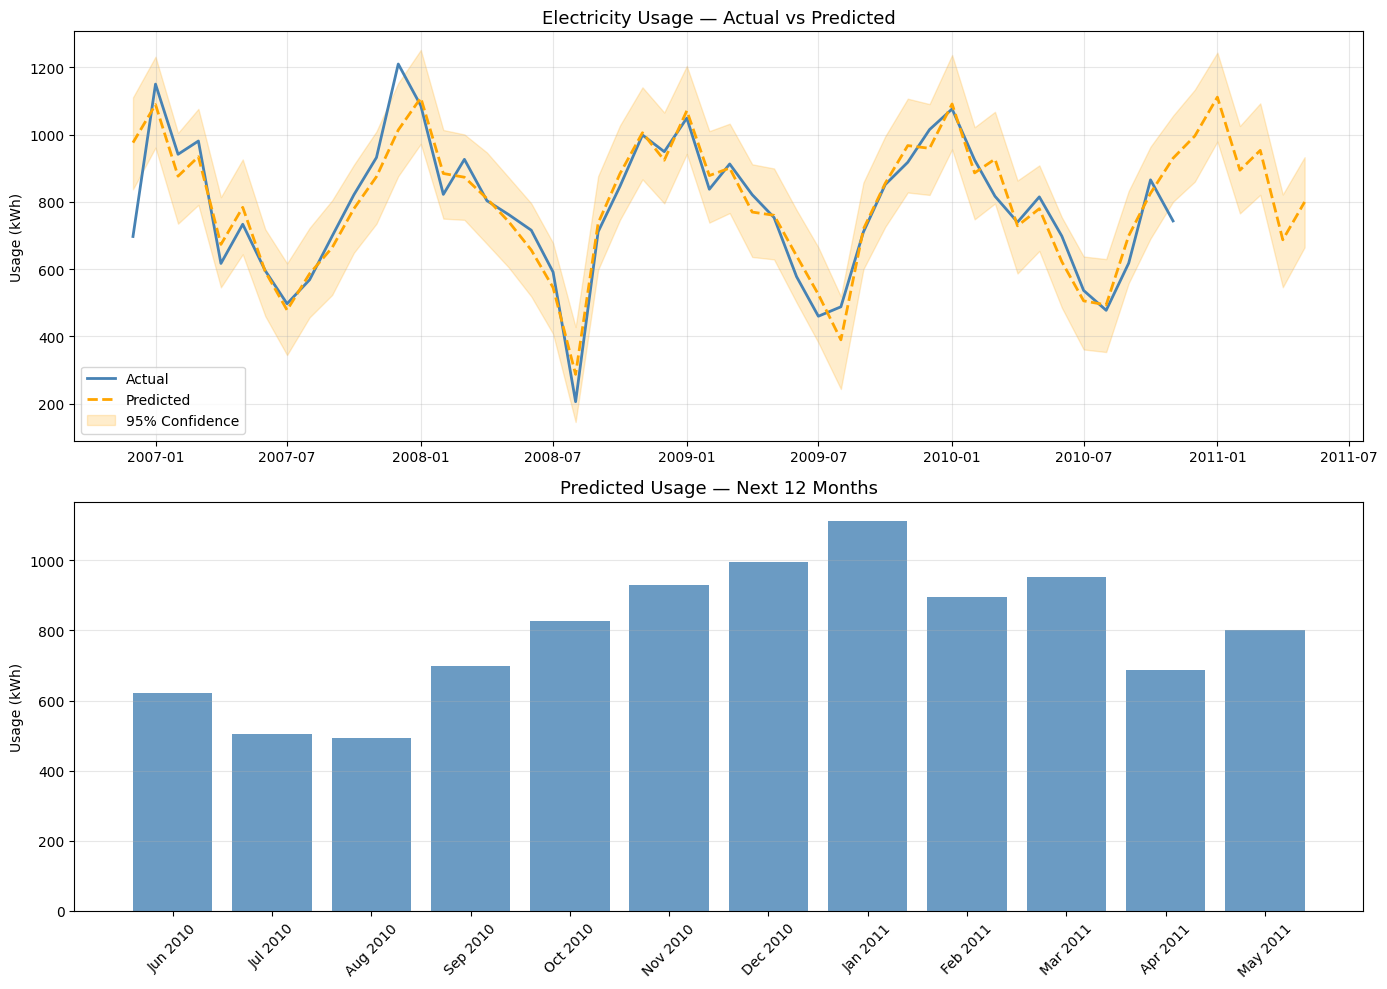

Plot saved!


In [9]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Full forecast
axes[0].plot(df_prophet['ds'], df_prophet['y'], 
             color='steelblue', label='Actual', linewidth=2)
axes[0].plot(forecast['ds'], forecast['yhat'], 
             color='orange', label='Predicted', linewidth=2, linestyle='--')
axes[0].fill_between(forecast['ds'], 
                      forecast['yhat_lower'], 
                      forecast['yhat_upper'], 
                      alpha=0.2, color='orange', label='95% Confidence')
axes[0].set_title('Electricity Usage — Actual vs Predicted', fontsize=13)
axes[0].set_ylabel('Usage (kWh)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Next 12 months only
future_only = forecast.tail(12)
axes[1].bar(future_only['ds'].dt.strftime('%b %Y'), 
            future_only['yhat'].round(1),
            color='steelblue', alpha=0.8)
axes[1].set_title('Predicted Usage — Next 12 Months', fontsize=13)
axes[1].set_ylabel('Usage (kWh)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../data/forecast_plot.png', dpi=150)
plt.show()
print("Plot saved!")

In [10]:
# Average electricity rate in India: ₹6 per kWh (adjust if needed)
RATE_PER_KWH = 6.0

next_3_months = forecast.tail(12).head(3)

print("=== Bill Estimate — Next 3 Months ===\n")
for _, row in next_3_months.iterrows():
    month     = row['ds'].strftime('%B %Y')
    kwh       = round(row['yhat'], 1)
    bill_low  = round(row['yhat_lower'] * RATE_PER_KWH, 0)
    bill_mid  = round(row['yhat'] * RATE_PER_KWH, 0)
    bill_high = round(row['yhat_upper'] * RATE_PER_KWH, 0)
    print(f"{month}")
    print(f"   Predicted usage : {kwh} kWh")
    print(f"   Estimated bill  : ₹{bill_low} – ₹{bill_mid} – ₹{bill_high}")
    print()

=== Bill Estimate — Next 3 Months ===

June 2010
   Predicted usage : 622.1 kWh
   Estimated bill  : ₹2912.0 – ₹3733.0 – ₹4524.0

July 2010
   Predicted usage : 505.7 kWh
   Estimated bill  : ₹2166.0 – ₹3034.0 – ₹3826.0

August 2010
   Predicted usage : 493.5 kWh
   Estimated bill  : ₹2120.0 – ₹2961.0 – ₹3779.0



In [11]:
import pickle
import os

# Create models folder if it doesn't exist
os.makedirs('../models', exist_ok=True)

# Save model
with open('../models/prophet_model.pkl', 'wb') as f:
    pickle.dump(model, f)

# Save forecast
forecast.to_csv('../data/forecast.csv', index=False)

print("Model saved → models/prophet_model.pkl")
print("Forecast saved → data/forecast.csv")
print()
print("=== Your project data folder now has: ===")
for file in os.listdir('../data'):
    print(f"   {file}")

Model saved → models/prophet_model.pkl
Forecast saved → data/forecast.csv

=== Your project data folder now has: ===
   cleaned_daily.csv
   cleaned_monthly.csv
   forecast.csv
   forecast_plot.png
   household_power_consumption.txt
   monthly_usage_plot.png
